In [1]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Fix random state for academic reproducibility
SEED = 42
np.random.seed(SEED)

# 1. Load the dataset
print("Loading UNSW-NB15 dataset...")
df = pd.read_csv("UNSW_NB15_training-set.csv")

print(f"Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Missing Values: {df.isnull().sum().max()}")

# 2. Target distribution (0 = Normal, 1 = Attack)
label_counts = df["label"].value_counts()
normal_pct = (label_counts[0] / len(df)) * 100
attack_pct = (label_counts[1] / len(df)) * 100

print(f"\nNormal Traffic (0): {label_counts[0]:,} ({normal_pct:.2f}%)")
print(f"Malicious Attacks (1): {label_counts[1]:,} ({attack_pct:.2f}%)")

# 3. Threat categories
print("\nThreat Categories Breakdown:")
print(df["attack_cat"].value_counts())


c:\Users\POWERSPEC\Desktop\AI Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading UNSW-NB15 dataset...
Dataset Dimensions: 82,332 rows, 45 columns
Missing Values: 0

Normal Traffic (0): 37,000 (44.94%)
Malicious Attacks (1): 45,332 (55.06%)

Threat Categories Breakdown:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [2]:
# 1. Feature / Target Separation
# 'id' is an arbitrary identifier, 'attack_cat' is multiclass, 'label' is binary target
X = df.drop(columns=["id", "attack_cat", "label"])
y = df["label"]

# 2. Encode Categorical Attributes ('proto', 'service', 'state')
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# 3. Stratified 80/20 Train-Test Split (leak-safe partitioning)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# 4. Outlier-Robust Normalization
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Baseline Classifier
print("Training Baseline Model (L2-Regularized Logistic Regression)...")
baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_model.fit(X_train_scaled, y_train)

# Evaluation
y_pred_base = baseline_model.predict(X_test_scaled)
y_prob_base = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Baseline Performance Metrics ---")
print(f"Accuracy:  {(y_test == y_pred_base).mean():.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_base):.4f}")

C:\Users\POWERSPEC\AppData\Local\Temp\ipykernel_11088\2496317776.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


Training Baseline Model (L2-Regularized Logistic Regression)...

--- Baseline Performance Metrics ---
Accuracy:  0.8314
Precision: 0.8594
Recall:    0.8295
F1-Score:  0.8442
ROC-AUC:   0.9238


c:\Users\POWERSPEC\Desktop\AI Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [3]:
print("Training Advanced Model (Gradient Boosted Trees - LightGBM)...")

# LightGBM handles non-linear relationships, multi-collinearity, and raw categorical features seamlessly
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

# Tree-based algorithms do not require feature scaling; we train directly on X_train
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("\n=== Advanced Model (LightGBM) Performance Metrics ===")
print(f"Accuracy:  {(y_test == y_pred_lgb).mean():.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lgb):.4f}")

# Detailed per-class precision and recall breakdown
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_lgb, target_names=["Normal Traffic (0)", "Malicious Attack (1)"]))

Training Advanced Model (Gradient Boosted Trees - LightGBM)...

=== Advanced Model (LightGBM) Performance Metrics ===
Accuracy:  0.9766
Precision: 0.9857
Recall:    0.9715
F1-Score:  0.9786
ROC-AUC:   0.9974

--- Detailed Classification Report ---
                      precision    recall  f1-score   support

  Normal Traffic (0)       0.97      0.98      0.97      7400
Malicious Attack (1)       0.99      0.97      0.98      9067

            accuracy                           0.98     16467
           macro avg       0.98      0.98      0.98     16467
        weighted avg       0.98      0.98      0.98     16467



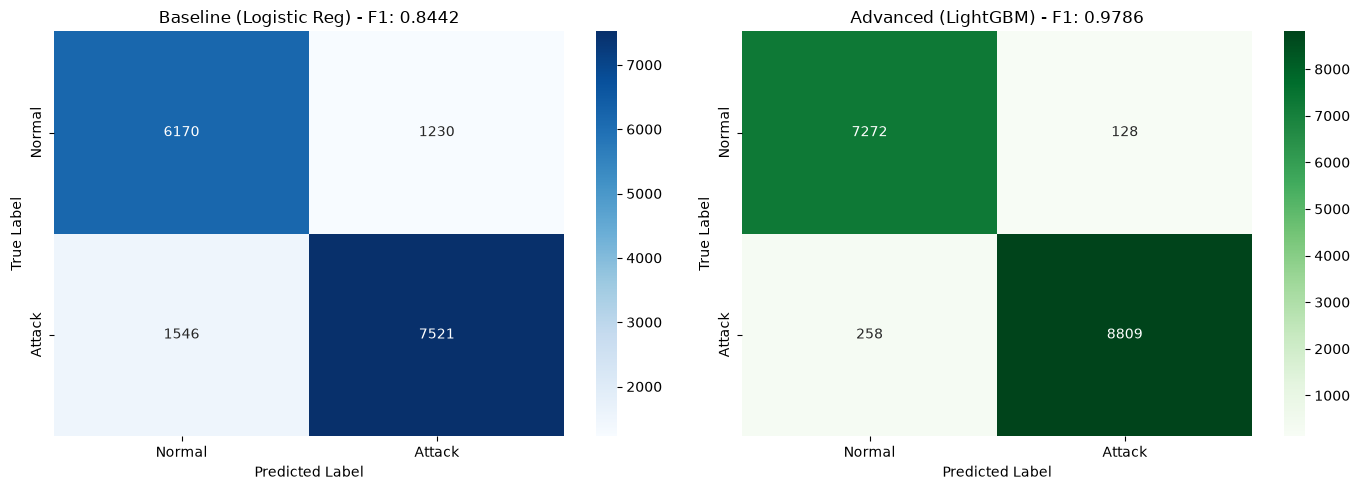

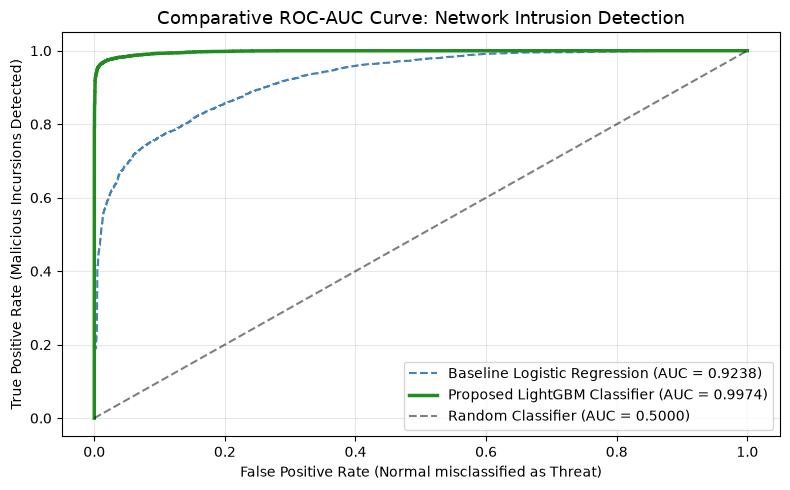

In [4]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
axes[0].set_title(f"Baseline (Logistic Reg) - F1: {f1_score(y_test, y_pred_base):.4f}", fontsize=12)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# LightGBM Confusion Matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
axes[1].set_title(f"Advanced (LightGBM) - F1: {f1_score(y_test, y_pred_lgb):.4f}", fontsize=12)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# Comparative ROC Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)

plt.figure(figsize=(8, 5))
plt.plot(fpr_base, tpr_base, label=f"Baseline Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_base):.4f})", linestyle="--", color="steelblue")
plt.plot(fpr_lgb, tpr_lgb, label=f"Proposed LightGBM Classifier (AUC = {roc_auc_score(y_test, y_prob_lgb):.4f})", color="forestgreen", linewidth=2.5)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier (AUC = 0.5000)")
plt.title("Comparative ROC-AUC Curve: Network Intrusion Detection", fontsize=13)
plt.xlabel("False Positive Rate (Normal misclassified as Threat)")
plt.ylabel("True Positive Rate (Malicious Incursions Detected)")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Calculating SHAP values for global network telemetry attribution...


c:\Users\POWERSPEC\Desktop\AI Project\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\POWERSPEC\AppData\Local\Temp\ipykernel_11088\3235124023.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(plot_vals, X_shap_sample, plot_type="bar", show=False, max_display=12)


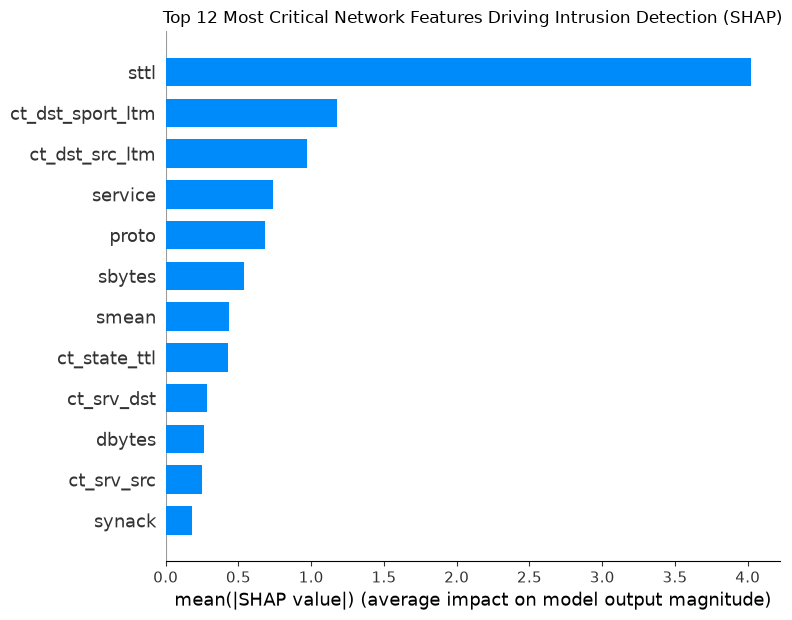

C:\Users\POWERSPEC\AppData\Local\Temp\ipykernel_11088\3235124023.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(plot_vals, X_shap_sample, show=False, max_display=12)


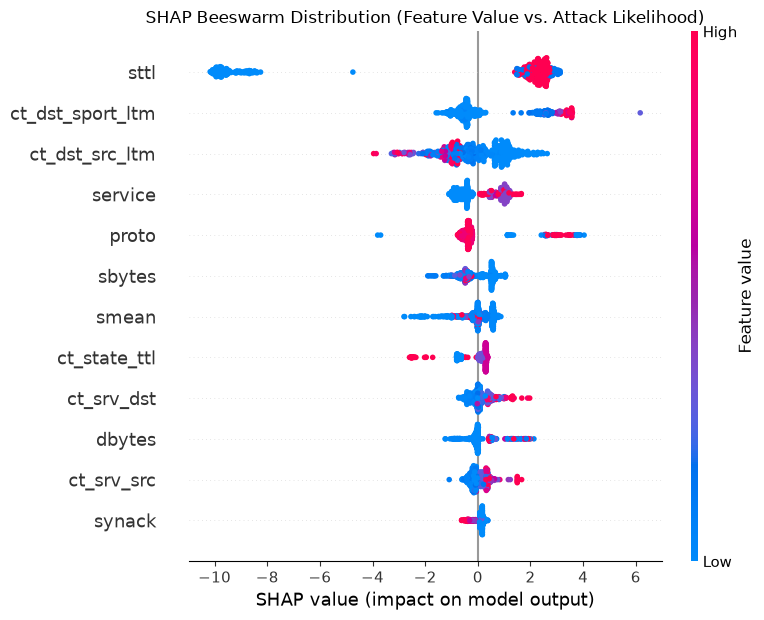

In [5]:
print("Calculating SHAP values for global network telemetry attribution...")

# Compute TreeSHAP over a representative 600-sample test cohort
sample_size = 600
X_shap_sample = X_test.iloc[:sample_size]

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_shap_sample)

# Normalize output shape across LightGBM/SHAP version conventions
if isinstance(shap_values, list):
    plot_vals = shap_values[1]
elif len(shap_values.shape) == 3:
    plot_vals = shap_values[:, :, 1]
else:
    plot_vals = shap_values

# 1. Global Bar Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(plot_vals, X_shap_sample, plot_type="bar", show=False, max_display=12)
plt.title("Top 12 Most Critical Network Features Driving Intrusion Detection (SHAP)", fontsize=12)
plt.tight_layout()
plt.show()

# 2. Detailed Beeswarm Plot (shows whether high/low values trigger attacks)
plt.figure(figsize=(10, 6))
shap.summary_plot(plot_vals, X_shap_sample, show=False, max_display=12)
plt.title("SHAP Beeswarm Distribution (Feature Value vs. Attack Likelihood)", fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
def inspect_network_packet(packet_index: int = 0):
    """
    Simulates a production Network Intrusion Detection Engine.
    Inspects a single connection stream, classifies threat likelihood,
    and extracts top driving factors via Shapley values.
    """
    raw_packet = X_test.iloc[[packet_index]]
    actual_label = y_test.iloc[packet_index]
    
    # Model inference
    pred_class = lgb_model.predict(raw_packet)[0]
    threat_prob = lgb_model.predict_proba(raw_packet)[0, 1]
    
    # Compute instance-level SHAP explanation
    sample_shap = explainer.shap_values(raw_packet)
    if isinstance(sample_shap, list):
        instance_vals = sample_shap[1][0]
    elif len(sample_shap.shape) == 3:
        instance_vals = sample_shap[0, :, 1]
    else:
        instance_vals = sample_shap[0]
        
    top_driver_idx = np.argsort(np.abs(instance_vals))[-3:][::-1]
    top_drivers = [(raw_packet.columns[i], raw_packet.iloc[0, i], instance_vals[i]) for i in top_driver_idx]
    
    status = "🚨 MALICIOUS INTRUSION DETECTED" if pred_class == 1 else "✅ BENIGN / NORMAL PACKET"
    
    print("=" * 60)
    print("       INTELLIGENT NETWORK PACKET AUDIT REPORT")
    print("=" * 60)
    print(f"Packet Index:       {packet_index}")
    print(f"Verdict:            {status}")
    print(f"Attack Probability: {threat_prob * 100:.2f}%")
    print(f"Ground Truth Label: {'Attack (1)' if actual_label == 1 else 'Normal (0)'}")
    print("-" * 60)
    print("Top Telemetry Influencing the Verdict:")
    for rank, (feat, val, impact) in enumerate(top_drivers, 1):
        direction = "Pushed toward ATTACK" if impact > 0 else "Pushed toward NORMAL"
        print(f"  {rank}. {feat} = {val} ({direction}, impact: {impact:+.4f})")
    print("=" * 60)

# Test the prototype on an intrusion sample and a normal sample
inspect_network_packet(packet_index=0)
inspect_network_packet(packet_index=15)

       INTELLIGENT NETWORK PACKET AUDIT REPORT
Packet Index:       0
Verdict:            🚨 MALICIOUS INTRUSION DETECTED
Attack Probability: 99.66%
Ground Truth Label: Attack (1)
------------------------------------------------------------
Top Telemetry Influencing the Verdict:
  1. ct_dst_sport_ltm = 3 (Pushed toward ATTACK, impact: +2.6909)
  2. sttl = 254 (Pushed toward ATTACK, impact: +2.4021)
  3. ct_dst_src_ltm = 6 (Pushed toward NORMAL, impact: -0.9426)
       INTELLIGENT NETWORK PACKET AUDIT REPORT
Packet Index:       15
Verdict:            🚨 MALICIOUS INTRUSION DETECTED
Attack Probability: 99.99%
Ground Truth Label: Attack (1)
------------------------------------------------------------
Top Telemetry Influencing the Verdict:
  1. proto = 118 (Pushed toward ATTACK, impact: +3.3507)
  2. sttl = 254 (Pushed toward ATTACK, impact: +2.6331)
  3. sbytes = 200 (Pushed toward ATTACK, impact: +0.6199)


c:\Users\POWERSPEC\Desktop\AI Project\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\POWERSPEC\Desktop\AI Project\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
